
Kr_R1s(r) =
+425.9315 * exp(-36.7205 r)
+301.0817 * r * exp(-31.1118 r)
-1.7777 * r * exp(-16.7539 r)
+1682.0880 * r^2 * exp(-45.1135 r)
-0.5617 * r^2 * exp(-12.5170 r)
-0.0334 * r^2 * exp(-8.5715 r)
-0.0025 * r^2 * exp(-6.2171 r)
+60.0851 * r^3 * exp(-19.6005 r)
-0.0002 * r^3 * exp(-3.8388 r)
+0.0000 * r^3 * exp(-2.5911 r)
-0.0000 * r^3 * exp(-1.8100 r)

Kr_R2s(r) =
-134.0259 * exp(-36.7205 r)
-1400.3931 * r * exp(-31.1118 r)
+1307.0744 * r * exp(-16.7539 r)
+7.0206 * r^2 * exp(-45.1135 r)
+392.6131 * r^2 * exp(-12.5170 r)
-8.7270 * r^2 * exp(-8.5715 r)
+1.1839 * r^2 * exp(-6.2171 r)
+8794.5937 * r^3 * exp(-19.6005 r)
-0.0339 * r^3 * exp(-3.8388 r)
+0.0028 * r^3 * exp(-2.5911 r)
-0.0002 * r^3 * exp(-1.8100 r)

Kr_R3s(r) =
+53.7770 * exp(-36.7205 r)
+665.2725 * r * exp(-31.1118 r)
-628.4793 * r * exp(-16.7539 r)
+134.4318 * r^2 * exp(-45.1135 r)
-383.3834 * r^2 * exp(-12.5170 r)
+451.3116 * r^2 * exp(-8.5715 r)
+162.8331 * r^2 * exp(-6.2171 r)
-9350.3812 * r^3 * exp(-19.6005 r)
+0.436

/tmp/ipykernel_330/1650046547.py:148: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999883919008787
Norm 2s = 0.999999866185717
Norm 2p = 0.9998375839216954
Norm 3s = 1.0000000444044508
Norm 3p = 0.9999989118725304
Norm 3d = 0.9999994260312418
Norm 4s = 1.0000011262372481
Norm 4p = 0.9999996689961429
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.024100           0.088105       2.263233e-01   
1       0.05           0.024100           0.088098       2.261898e-01   
2       0.10           0.024099           0.088077       2.257896e-01   
3       0.15           0.024098           0.088042       2.251245e-01   
4       0.20           0.024097           0.087994       2.241972e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000035           0.000004       6.596657e-07   
1997   99.85           0.000035           0.000004       6.578131e-07   
1998   99.90           0.000034           0.000004       6.559664e-07   
1999   99.95           0.000034        

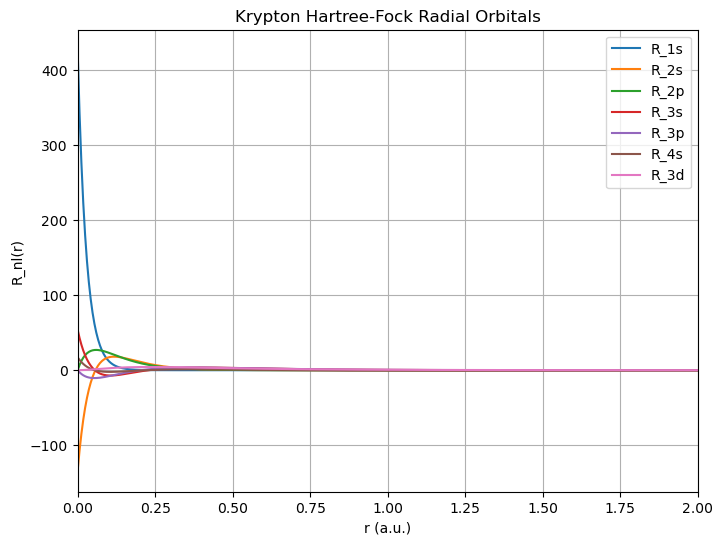

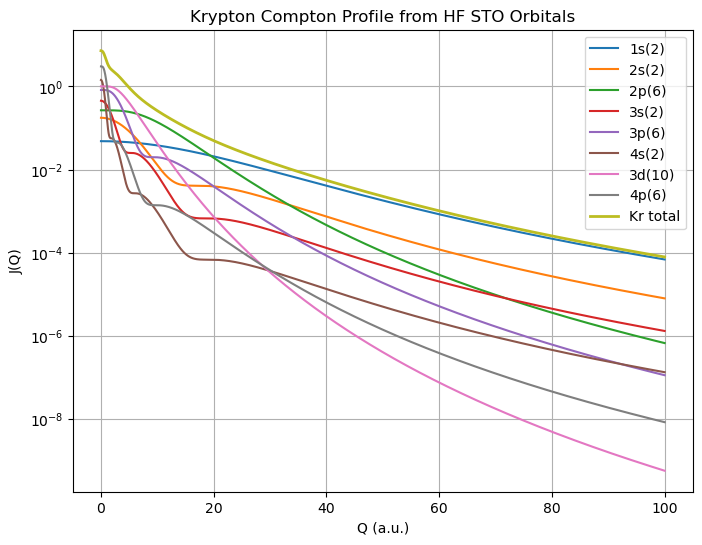

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Krypton Hartree-Fock STO data
# Kr: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(6)
# Ground term: 1S
# Format: (n_j, Z_j, C_j)
# =====================================================

krypton_1s = [
    (1, 36.7205,  0.957077),
    (2, 31.1118,  0.048295),
    (2, 16.7539, -0.001340),
    (3, 45.1135,  0.006469),
    (3, 12.5170, -0.000192),
    (3,  8.5715, -0.000043),
    (3,  6.2171, -0.000010),
    (4, 19.6005,  0.000816),
    (4,  3.8388, -0.000004),
    (4,  2.5911,  0.000005),
    (4,  1.8100, -0.000001),
]

krypton_2s = [
    (1, 36.7205, -0.301159),
    (2, 31.1118, -0.224630),
    (2, 16.7539,  0.985238),
    (3, 45.1135,  0.000027),
    (3, 12.5170,  0.134207),
    (3,  8.5715, -0.011226),
    (3,  6.2171,  0.004686),
    (4, 19.6005,  0.119437),
    (4,  3.8388, -0.000706),
    (4,  2.5911,  0.000347),
    (4,  1.8100, -0.000119),
]

krypton_3s = [
    (1, 36.7205,  0.120838),
    (2, 31.1118,  0.106713),
    (2, 16.7539, -0.473731),
    (3, 45.1135,  0.000517),
    (3, 12.5170, -0.131052),
    (3,  8.5715,  0.580549),
    (3,  6.2171,  0.644535),
    (4, 19.6005, -0.126985),
    (4,  3.8388,  0.009105),
    (4,  2.5911, -0.001109),
    (4,  1.8100,  0.000560),
]

krypton_4s = [
    (1, 36.7205,  0.038487),
    (2, 31.1118,  0.035084),
    (2, 16.7539, -0.155808),
    (3, 45.1135,  0.000102),
    (3, 12.5170, -0.037482),
    (3,  8.5715,  0.196315),
    (3,  6.2171,  0.295835),
    (4, 19.6005, -0.048888),
    (4,  3.8388, -0.476243),
    (4,  2.5911, -0.530291),
    (4,  1.8100, -0.151842),
]

krypton_2p = [
    (2, 38.0283,  0.054135),
    (2, 14.6932,  0.751976),
    (3, 31.3136,  0.118384),
    (3, 11.7833,  0.044500),
    (3,  7.4972,  0.001287),
    (4,  5.3888,  0.000557),
    (4, 25.3638,  0.076875),
    (4,  3.5216, -0.000045),
    (4,  2.2424, -0.000013),
    (4,  1.4475, -0.000004),
]

krypton_3p = [
    (2, 38.0283, -0.001435),
    (2, 14.6932, -0.526859),
    (3, 31.3136,  0.009958),
    (3, 11.7833,  0.120509),
    (3,  7.4972,  0.646740),
    (3,  5.3888,  0.401547),
    (4, 25.3638,  0.032338),
    (4,  3.5216,  0.006341),
    (4,  2.2424, -0.000025),
    (4,  1.4475,  0.000066),
]

krypton_4p = [
    (2, 38.0283,  0.001213),
    (2, 14.6932, -0.160462),
    (3, 31.3136,  0.007447),
    (3, 11.7833,  0.045141),
    (3,  7.4972,  0.191368),
    (3,  5.3888,  0.141683),
    (4, 25.3638,  0.014153),
    (4,  3.5216, -0.393849),
    (4,  2.2424, -0.538338),
    (4,  1.4475, -0.225021),
]

krypton_3d = [
    (3, 19.1294,  0.015286),
    (3, 10.7158,  0.245430),
    (3,  6.6805,  0.473937),
    (3,  4.4322,  0.335752),
    (3,  2.7599,  0.031469),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, krypton_1s)
R2s = R_nl(r, krypton_2s)
R3s = R_nl(r, krypton_3s)
R4s = R_nl(r, krypton_4s)
R2p = R_nl(r, krypton_2p)
R3p = R_nl(r, krypton_3p)
R3d = R_nl(r, krypton_3d)
R4p = R_nl(r, krypton_4p)

print_R_formula(krypton_1s, "Kr_R1s")
print_R_formula(krypton_2s, "Kr_R2s")
print_R_formula(krypton_3s, "Kr_R3s")
print_R_formula(krypton_4s, "Kr_R4s")
print_R_formula(krypton_2p, "Kr_R2p")
print_R_formula(krypton_3p, "Kr_R3p")
print_R_formula(krypton_3d, "Kr_R3d")
print_R_formula(krypton_4p, "Kr_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(6)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 6*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(2)": 6*J_4p,
    "J_total_Kr": J_total
    })
print(table)
table.to_csv("Krypton__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Krypton Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 6*J_4p, label="4p(6)")
plt.plot(Q, J_total, label="Kr total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Krypton Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()
